# Content-Based Course Recommendations and EDA Notebook

In everyday life, a striking example showcasing the power of content-based recommendation systems lies within online shopping platforms. For instance, on a platform like Amazon, when a user purchases a book, the platform suggests other similar books based on the content of the purchased book. These recommendations are made based on factors such as the content, author, category of the book, and user preferences for similar books.

However, the prowess of content-based recommendation systems extends beyond e-commerce. For example, an online education platform like Coursera recommends new courses to users based on their previous course enrollments or interests. Let's say a user has taken a course on mathematics. **Coursera could employ a content-based approach to personalize recommendations by suggesting other mathematics-related courses, lessons from instructors specialized in mathematics, and supplementary materials.** This way, users can have more tailored and satisfying learning experiences based on their interests. This example illustrates how content-based recommendation systems can be utilized in real-world applications and cater to the needs of users.

**Content Outline:**

1. **EDA and Data Preprocessing**

Data preprocessing is a critical step in preparing our dataset for analysis. In this section, we will address steps such as data cleaning, normalization, and feature extraction. By ensuring the quality and integrity of our data, we will establish a solid foundation for subsequent analyses.

2. **Construction of the TF-IDF Matrix**

The creation of the TF-IDF (Term Frequency-Inverse Document Frequency) matrix forms the backbone of content-based recommendation systems. In this section, we will examine the process of constructing this matrix and explore the role of measuring the importance of terms in textual data. We will demonstrate how TF-IDF allows for the extraction of significant features from textual data and facilitates complex analyses.

3. **Construction of the Cosine Similarity Matrix**

Cosine similarity serves as a fundamental metric in measuring similarity when documents are represented as vectors. In this section, we will explain the concept of cosine similarity and its significance in content-based recommendation systems. By constructing cosine similarity matrices, we will pave the way for comparing course content, ultimately enabling the creation of personalized recommendations based on individual user preferences.

4. **Generating Recommendations Based on Similarity**

Building upon the work conducted in previous sections, we transition to the steps for generating recommendations based on content similarity. By combining TF-IDF matrices and cosine similarity computations, we will demonstrate how to utilize these techniques to provide personalized course recommendations. Our aim is to cater to the unique learning objectives and preferences of users by delivering personalized recommendations for online education platforms.

---

## Introduction

Welcome to our exploration of content-based course recommendations! 🚀 In this article, we embark on a fascinating journey into the realm of personalized learning experiences driven by cutting-edge data processing techniques.

As the digital landscape burgeons with an abundance of educational resources 📚, the quest for tailored and relevant course suggestions has become increasingly paramount. In response to this demand, we delve deep into the realm of content-based recommendation systems, leveraging advanced methodologies to meet the unique needs of learners.

At the heart of our methodology lies TF-IDF (Term Frequency-Inverse Document Frequency), a powerful tool that illuminates the significance of terms within a corpus of documents 📝. Through TF-IDF, we gain insights into the key features of textual data, enabling nuanced analysis and recommendation generation.

But that's not all! 🌟 We also unravel the essence of Cosine Similarity, a metric pivotal in quantifying the similarity between documents represented as vectors. By comprehending its essence, we uncover how it facilitates the comparison of course content and underpins the foundation of our recommendation system.

Through this exploration, our aim is twofold. 🎯 Not only do we provide technical insights into the construction of TF-IDF matrices and cosine similarity computations, but we also shed light on the practical implications of content-based recommendations. We delve into how these techniques can revolutionize the landscape for online course platforms, empowering them to deliver tailored suggestions that resonate with the unique learning preferences and objectives of their users.

So, join us as we unravel the mysteries of content-based course recommendations and embark on a journey towards personalized learning excellence! 🌟

---

## About Dataset

**Key Variables from the Dataset 📊**

- **Course Title**: Reflects the title of the course.
- **Course Organization**: Indicates the institution or organization offering the course.
- **Course Certificate Type**: Specifies the type of certificate awarded upon completion (specialization, certificate, course, etc.).
- **Course Rating**: Provides the rating of the course (could be None).
- **Course Review Number**: Represents the number of reviews for the course (could be None).
- **Course Time**: Estimates the time required to complete the program, formatted as x - y Months (e.g., 1 - 3 Months).
- **Course Difficulty**: Indicates the difficulty level of the course (Beginner, Intermediate, Advanced, Mixed).
- **Course Students Enrolled**: Specifies the number of students enrolled in the course.

**Additional Fields 🌟**

- **Course URL**: Direct link to the course webpage.
- **Course Skills**: Lists the skills learners will gain from the course, as per the course webpage (could be empty).
- **Course Summary**: Provides bullet points summarizing the "What you'll learn" section of the course (could be empty).
- **Course Description**: Offers a detailed description of the course provided by the organization, typically located in the lower half of the webpage.

---

# 1. Exploratory Data Analysis

In [1]:
import os
import re

import numpy as np
import pandas as pd
# Pandas Configuration
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 500)
pd.set_option('display.expand_frame_repr', False)

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

In [2]:
df_ = pd.read_csv("/kaggle/input/coursera-course-dataset/coursera_courses.csv")
df_.drop("course_url", axis=1,inplace=True)
df= df_.copy()
print("################## Head ####################")
df.head()

################## Head ####################


,course_title,course_organization,course_certificate_type,course_time,course_rating,course_reviews_num,course_difficulty,course_students_enrolled,course_skills,course_summary,course_description
0,(ISC)² Systems Security Certified Practitioner...,ISC2,Specialization,3 - 6 Months,4.7,492,Beginner,"6,958","['Risk Management', 'Access Control', 'Asset',...",[],Pursue better IT security job opportunities an...
1,.NET FullStack Developer,Board Infinity,Specialization,1 - 3 Months,4.3,51,Intermediate,"2,531","['Web API', 'Web Development', 'Cascading Styl...",['Master .NET full stack web dev: from .NET co...,Develop the proficiency required to design and...
2,21st Century Energy Transition: how do we make...,University of Alberta,Course,1 - 3 Months,4.8,62,Beginner,"4,377",[],['Understand the complexity of systems supplyi...,"Affordable, abundant and reliable energy is fu..."
3,A Crash Course in Causality: Inferring Causal...,University of Pennsylvania,Course,1 - 3 Months,4.7,517,Intermediate,"39,004","['Instrumental Variable', 'Propensity Score Ma...",[],We have all heard the phrase “correlation does...
4,A life with ADHD,University of Geneva,Course,1 - 3 Months,NaN,NaN,Beginner,NaN,"['differential diagnosis and comorbidities', '...",[' Understand what ADHD is and the challenges ...,What is ADHD and what are the challenges that ...


In [3]:
print("################## Tail ####################")
df.tail()

################## Tail ####################


,course_title,course_organization,course_certificate_type,course_time,course_rating,course_reviews_num,course_difficulty,course_students_enrolled,course_skills,course_summary,course_description
995,Étudier en France: French Intermediate course ...,École Polytechnique,Course,1 - 3 Months,4.8,4.6k,Intermediate,"519,333",[],[],Ce cours de français de niveau intermédiaire B...
996,Цифровий маркетинг і електронна комерція від G...,Google,Professional Certificate,3 - 6 Months,4.9,1.2k,Beginner,"7,630","['Медійна реклама', 'Маркетинг', 'Маркетинг ел...",['Ви вивчите основи цифрового маркетингу та ел...,"За менш ніж шість місяців, без досвіду або спе..."
997,تحليلات البيانات من Google,Google,Professional Certificate,3 - 6 Months,4.8,156,Beginner,"2,701","['مؤثرات عرض البيانات (DataViz)', 'R Markdown'...",['اكتساب فهم شامل للممارسات والعمليات التي يست...,استعد لمهنة جديدة في مجال تحليلات البيانات عال...
998,用 Python 做商管程式設計（一）(Programming for Business C...,National Taiwan University,Course,1 - 3 Months,4.9,814,Beginner,"38,595",[],[],本系列課程從零開始，教授一般認為最適合初學者的程式語言「Python」，目標是讓大家在完成本...
999,用 Python 做商管程式設計（二）(Programming for Business C...,National Taiwan University,Course,1 - 4 Weeks,4.6,249,Intermediate,"10,432",[],[],接續用 Python 做商管程式設計（一）的內容，我們將在這個課程中繼續探討Python語言...


In [4]:
def check_df(dataframe, head=5):
    print("################## Shape ####################")
    print(dataframe.shape)
    print("################## Types ####################")
    print(dataframe.dtypes)
    print("################## NA ####################")
    print(dataframe.isnull().sum())
    print("################## Quantiles ####################")
    print(dataframe.describe([0.05, 0.10, 0.25, 0.40, 0.50, 0.60, 0.75, 0.90, 0.95]).T)
    
check_df(df)

################## Shape ####################
(1000, 11)
################## Types ####################
course_title                 object
course_organization          object
course_certificate_type      object
course_time                  object
course_rating               float64
course_reviews_num           object
course_difficulty            object
course_students_enrolled     object
course_skills                object
course_summary               object
course_description           object
dtype: object
################## NA ####################
course_title                 0
course_organization          0
course_certificate_type      0
course_time                  0
course_rating                6
course_reviews_num           6
course_difficulty            0
course_students_enrolled    41
course_skills                0
course_summary               0
course_description           1
dtype: int64
################## Quantiles ####################
               count     mean       std 

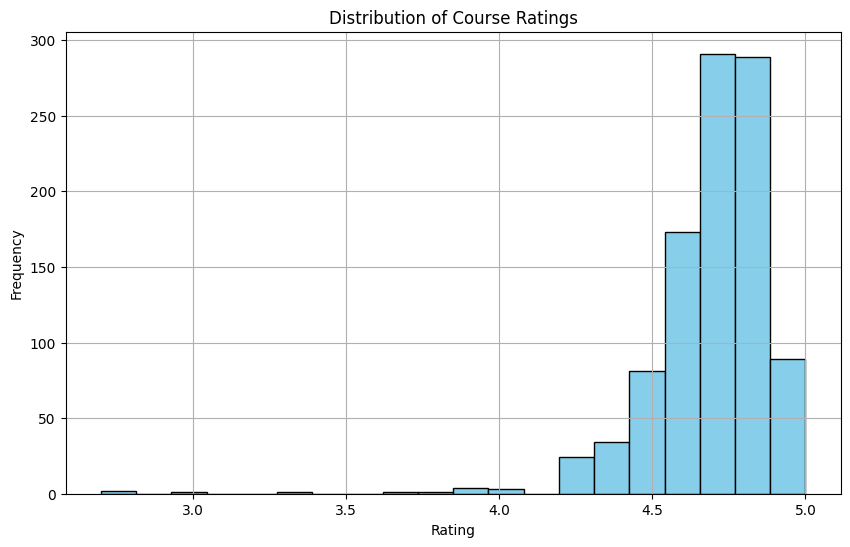

In [5]:
import matplotlib.pyplot as plt

# Visualizing the distribution of ratings
plt.figure(figsize=(10, 6))
plt.hist(df['course_rating'], bins=20, color='skyblue', edgecolor='black')
plt.title('Distribution of Course Ratings')
plt.xlabel('Rating')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

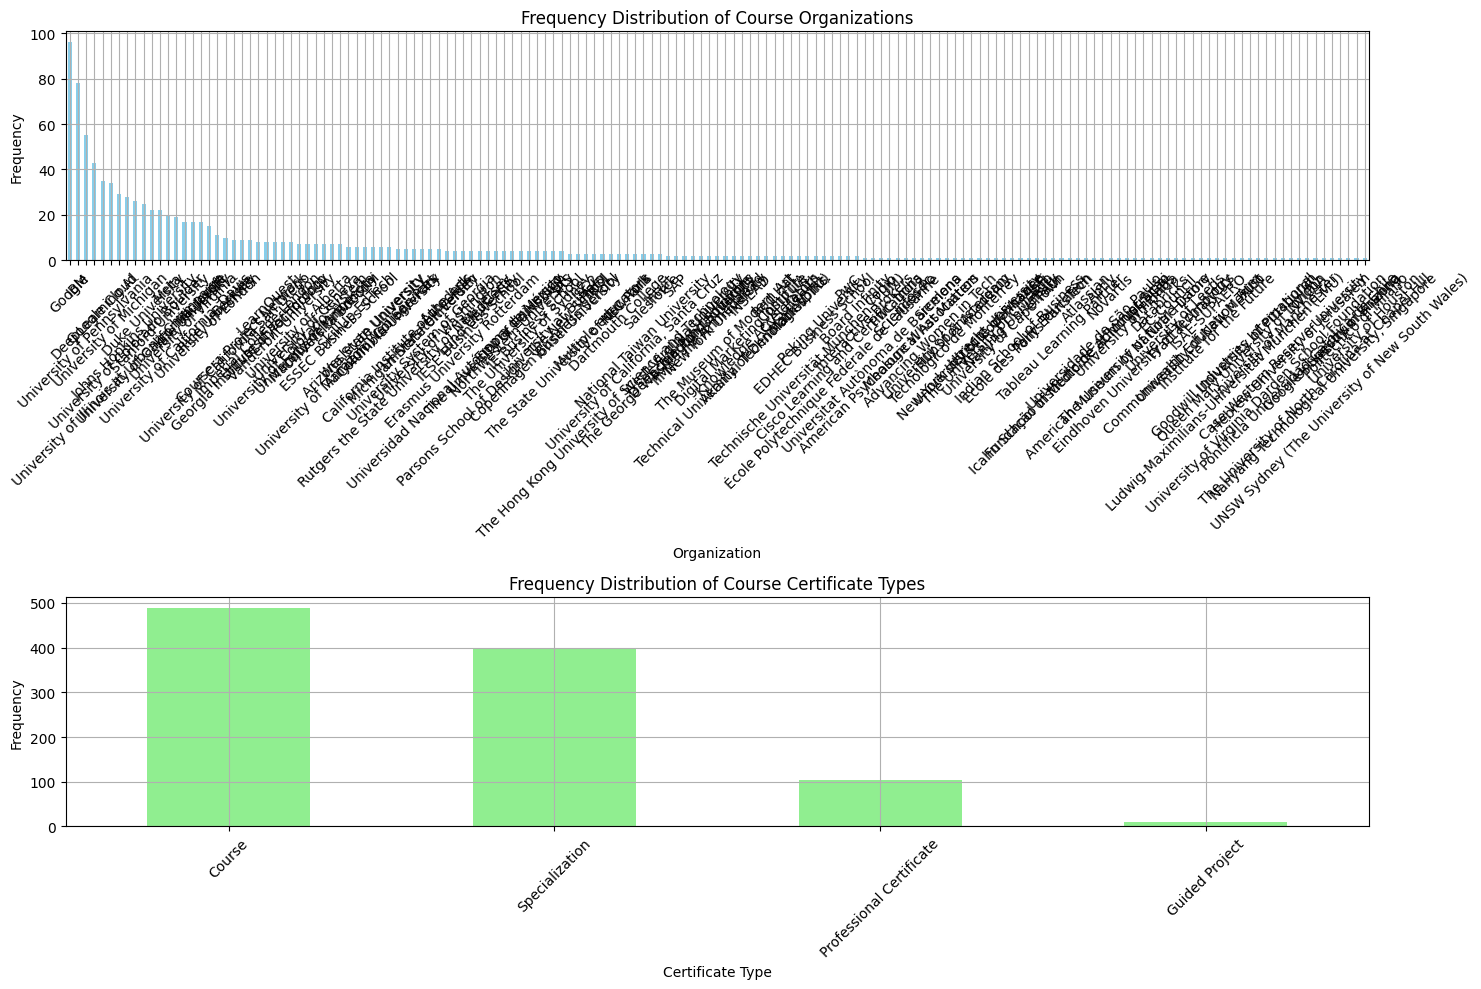

In [6]:
import matplotlib.pyplot as plt

# Visualizing the frequency distribution of categorical variables
plt.figure(figsize=(15, 10))

# Frequency distribution of course organizations
plt.subplot(2, 1, 1)
df['course_organization'].value_counts().plot(kind='bar', color='skyblue')
plt.title('Frequency Distribution of Course Organizations')
plt.xlabel('Organization')
plt.ylabel('Frequency')
plt.xticks(rotation=45)
plt.grid(True)

# Frequency distribution of course certificate types
plt.subplot(2, 1, 2)
df['course_certificate_type'].value_counts().plot(kind='bar', color='lightgreen')
plt.title('Frequency Distribution of Course Certificate Types')
plt.xlabel('Certificate Type')
plt.ylabel('Frequency')
plt.xticks(rotation=45)
plt.grid(True)

plt.tight_layout()
plt.show()

---
# 1. Data Preprocessing

In [7]:
# Fill missing values in 'course_students_enrolled' with the mean
mean_students_enrolled = df["course_students_enrolled"].str.replace(",", "").astype(float).mean()
df["course_students_enrolled"].fillna(mean_students_enrolled, inplace=True)

# Drop rows with missing values in 'course_description'
df.dropna(subset=['course_description'], inplace=True)

In [8]:
df["course_students_enrolled"].isnull().any()

False

In [9]:
df["course_description"].isnull().any()

False

**Regular Expressions (Regex): A Brief Overview**

Regular expressions, often abbreviated as regex, are powerful tools for pattern matching and text manipulation in programming languages. With regex, you can search for specific patterns within strings of text and perform various operations such as finding, replacing, and extracting substrings based on those patterns.

In regex, special characters and metacharacters are used to define patterns. For example, '*' represents zero or more occurrences of the preceding character, '?' represents zero or one occurrence, and '.' represents any single character.

Here's a simple example of how regex works:

```python
import re

# Define a pattern
pattern = r'ab*'

# Search for the pattern in a string
text = 'ababbba'
matches = re.findall(pattern, text)
print(matches)  
# Output: ['ab', 'abbb', 'a']

"""
In this example, the pattern 'ab*' matches 'a' followed by zero or more 'b's. The 're.findall()' function searches the 'text' string for all occurrences of this pattern and returns them as a list.
"""
```

Regex provides a flexible and efficient way to work with textual data, making it a valuable tool for tasks such as data cleaning, text processing, and pattern recognition.

In [10]:
df['course_description'].head()

0    Pursue better IT security job opportunities an...
1    Develop the proficiency required to design and...
2    Affordable, abundant and reliable energy is fu...
3    We have all heard the phrase “correlation does...
4    What is ADHD and what are the challenges that ...
Name: course_description, dtype: object

In [11]:
df['course_description'] = df['course_description'].apply(lambda x: re.sub(r'[-.:,“]', ' ', x))
df['course_description'].head()

0    Pursue better IT security job opportunities an...
1    Develop the proficiency required to design and...
2    Affordable  abundant and reliable energy is fu...
3    We have all heard the phrase  correlation does...
4    What is ADHD and what are the challenges that ...
Name: course_description, dtype: object

---
# 2. Construction of the TF-IDF Matrix

In [12]:
# This line checks if there are any missing values in the 'course_description' column and prints the result.
print(df["course_description"].isnull().any())

#  If there are missing values in the 'course_description' column, it fills them with an empty string.
df['course_description'] = df['course_description'].fillna('')

# Initializes the TF-IDF vectorizer. The parameter 'stop_words='english'' prevents the use of English stop words, \
# which are common but semantically insignificant words.
tfidf = TfidfVectorizer(stop_words='english')

False


In [13]:
# Converts the text data in the 'course_description' column into a TF-IDF matrix. \
# This matrix contains the TF-IDF weights of each word in each document.
tfidf_matrix = tfidf.fit_transform(df['course_description'])

In [14]:
# Returns the feature names (i.e., each word in each column) of the TF-IDF vectorizer.
tfidf.get_feature_names_out

<bound method CountVectorizer.get_feature_names_out of TfidfVectorizer(stop_words='english')>

In [15]:
# Converts the TF-IDF matrix to a NumPy array. \
# This can be useful for visualizing the contents of the matrix.
tfidf_matrix.toarray()

array([[0.06213267, 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       ...,
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ]])

---
# 3. Construction of the Cosine Similarity Matrix

In [16]:
# Computes the similarities between documents using the cosine similarity metric based on the TF-IDF matrix.
similarity = cosine_similarity(tfidf_matrix,
                               tfidf_matrix)

In [17]:
similarity

array([[1.00000000e+00, 1.41317610e-02, 1.88098194e-02, ...,
        1.18091568e-03, 0.00000000e+00, 0.00000000e+00],
       [1.41317610e-02, 1.00000000e+00, 2.25333328e-03, ...,
        3.88138742e-04, 0.00000000e+00, 0.00000000e+00],
       [1.88098194e-02, 2.25333328e-03, 1.00000000e+00, ...,
        2.55301963e-04, 0.00000000e+00, 0.00000000e+00],
       ...,
       [1.18091568e-03, 3.88138742e-04, 2.55301963e-04, ...,
        1.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
        0.00000000e+00, 1.00000000e+00, 2.07537539e-02],
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
        0.00000000e+00, 2.07537539e-02, 1.00000000e+00]])

---
# 4. Generating Recommendations Based on Similarity

In [18]:
# Creates a Series using the 'course_title' column as the index. \
# This contains the indices corresponding to each course title.
indices = pd.Series(df.index, index=df['course_title']).drop_duplicates()

In [19]:
indices[0:10]

course_title
(ISC)² Systems Security Certified Practitioner (SSCP)                             0
.NET FullStack Developer                                                          1
21st Century Energy Transition: how do we make it work?                           2
A Crash Course in Causality:  Inferring Causal Effects from Observational Data    3
A life with ADHD                                                                  4
AI & Law                                                                          5
AI Applications in Marketing and Finance                                          6
AI Applications in People Management                                              7
AI For Business                                                                   8
AI For Everyone                                                                   9
dtype: int64

In [20]:
indices.index.value_counts()

course_title
Machine Learning                                                         2
Google UX Design                                                         2
Business Analytics                                                       2
Introduction to Psychology                                               2
Introduction to Project Management                                       2
                                                                        ..
Financial Management                                                     1
Financial Markets                                                        1
Financial Planning for Young Adults                                      1
Financial Reporting                                                      1
用 Python 做商管程式設計（二）(Programming for Business Computing in Python (2))    1
Name: count, Length: 992, dtype: int64

In [21]:
# If multiple courses have the same title,\
# it keeps only the last one. This ensures that each course has a unique index.
indices = indices[~indices.index.duplicated(keep='last')]

In [22]:
# Finds the index of the course with the title 'Data Science'.
course_index = indices["Data Science"]

# Retrieves an array containing the similarities of the 'Data Science' course with other courses.
similarity[course_index]

array([1.45719627e-02, 1.76195056e-02, 0.00000000e+00, 2.28985351e-01,
       2.83096754e-03, 9.18772513e-03, 1.03398001e-02, 2.38446868e-02,
       6.20171593e-02, 1.63237866e-02, 2.05859693e-03, 2.90928705e-02,
       2.28794727e-02, 3.52664589e-02, 7.24629073e-02, 4.10475818e-03,
       5.93971732e-03, 2.22571417e-02, 2.76515031e-02, 4.65142637e-02,
       2.76490147e-02, 3.42690739e-02, 8.96241749e-03, 0.00000000e+00,
       3.20926808e-03, 1.18000453e-02, 7.38473238e-03, 2.41835256e-02,
       1.43170728e-02, 1.89329180e-02, 5.47255451e-02, 2.86375266e-02,
       1.13671010e-02, 5.77724483e-02, 7.02193616e-03, 1.75421230e-01,
       4.56794328e-02, 2.09977909e-02, 5.74546321e-02, 3.33476345e-02,
       4.00022596e-02, 2.67217587e-02, 3.59468943e-02, 1.91498528e-02,
       8.55360059e-03, 2.60280856e-02, 2.17690124e-02, 9.36532242e-03,
       7.41658560e-02, 4.09816034e-02, 1.23531927e-02, 0.00000000e+00,
       1.46599528e-02, 0.00000000e+00, 0.00000000e+00, 3.80105930e-02,
      

In [23]:
# Creates a DataFrame containing the similarity scores.
similarity_scores = pd.DataFrame(similarity[course_index],
                                 columns=["score"])

In [24]:
# Sorts the similarity scores in descending order and selects the top 10 highest scores. \
# The '1:11' slice excludes the course with the highest similarity score, as it would be the course itself.
course_indices = similarity_scores.sort_values("score", ascending=False)[1:11].index

In [25]:
# Retrieves a list of the titles of the top 10 courses with the highest similarity scores.
df['course_title'].iloc[course_indices]

707            Methods and Statistics in Social Sciences
3      A Crash Course in Causality:  Inferring Causal...
218                         Data Engineering Foundations
817                               Psychological Research
899                               Statistics with Python
126      Business Sustainability in the Circular Economy
385               Fundamentals of Reinforcement Learning
104                                Blockchain Revolution
35                           Advanced Business Analytics
776                                   Pre-MBA Statistics
Name: course_title, dtype: object

In [26]:
# Final Function
def get_recommendations_course(title, cosine_sim=similarity):
    indices = pd.Series(df.index, index=df['course_title']).drop_duplicates()
    indices = indices[~indices.index.duplicated(keep='last')]
    course_index = indices[title]
    cosine_sim[course_index]
    similarity_scores = pd.DataFrame(cosine_sim[course_index],
                                 columns=["score"])
    course_indices = similarity_scores.sort_values("score", ascending=False)[1:11].index
    return df['course_title'].iloc[course_indices]

In [27]:
get_recommendations_course('Pre-MBA Statistics')

143                        Certified in Cybersecurity
932                       The Business of Health Care
404             Geographic Information Systems  (GIS)
916                 Systems Biology and Biotechnology
260           Digital Marketing Strategy and Planning
364    Foundations of Software Testing and Validation
104                             Blockchain Revolution
463                                    Healthcare Law
20                                    AI for Medicine
898     Statistical Analysis with R for Public Health
Name: course_title, dtype: object

In [28]:
get_recommendations_course('Psychological Research')

357                          Foundations of Data Science
768       Politics and Economics of International Energy
427                                Google Data Analytics
212    Data Analysis and Presentation Skills: the PwC...
84                   Astronomy: Exploring Time and Space
557                       Introduction to Data Analytics
91     BI Foundations with SQL, ETL and Data Warehousing
951                    Tools of the Trade: Linux and SQL
166                           Computational Neuroscience
213          Data Analysis and Visualization Foundations
Name: course_title, dtype: object

---
# 📝 Summary 

- We initiated by addressing missing values in the 'course_description' column and filled any gaps with an empty string. Utilizing the TF-IDF method, we transformed textual descriptions of courses into numerical representations, enabling us to compute the cosine similarity matrix. 🔍

- Subsequently, this similarity matrix facilitated quantification of the likeness between each pair of courses. By employing distance-based measures, such as cosine similarity, we determined the top 10 courses most akin to the 'Data Science' course. 📊

- This methodology highlights the significance of leveraging content-based approaches in recommendation systems. By emphasizing matrix operations and distance metrics, we enhance users' experience by providing personalized course recommendations grounded in the content they prefer. 🚀

---

# 🎓 Conclusion 🚀

1. **Enhanced User Experience:** Content-based recommendation systems utilizing techniques like TF-IDF and cosine similarity offer personalized course suggestions, enhancing user satisfaction by providing relevant recommendations tailored to their interests.

2. **Mitigated Information Overload:** By leveraging content analysis, these systems alleviate common issues such as information overload and decision paralysis, ensuring users are presented with manageable and relevant options.

3. **Improved Engagement:** Understanding users' preferences through content analysis allows educational platforms to optimize their offerings, leading to improved user engagement and retention rates.

4. **Business Growth:** By driving user engagement and satisfaction, content-based recommendation systems contribute to the growth and success of educational platforms, ultimately achieving business objectives in the competitive online education landscape.

In essence, content-based recommendation systems play a vital role in meeting the diverse learning needs of users while simultaneously driving business growth and success. 🌟📚